# Next visit dementia progression prediction architecture workflow figure

All plotting logic is organized into reusable functions. The final cell calls one function to generate and save the workflow image.

In [1]:
from pathlib import Path
from dataclasses import dataclass
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display


In [2]:
@dataclass(frozen=True)
class ProjectValues:
    """Audited PP_DementiaProgress v2.14 counts used in the workflow figure."""
    prepared_visit_rows: int = 188_700
    eligible_visits: int = 23_665
    unique_participants: int = 10_671
    progression_events: int = 4_390
    training_visits: int = 16_593
    validation_visits: int = 2_348
    test_visits: int = 4_724
    temporal_training_visits: int = 19_352
    temporal_test_visits: int = 4_313


@dataclass(frozen=True)
class Layout:
    """Canvas and spacing controls for the architecture workflow figure."""
    W: int = 2400
    H: int = 1850

    title_y: int = 55

    full_x: int = 260
    full_w: int = 1880
    full_h: int = 145

    data_y: int = 175
    cohort_y: int = 400

    branch_y: int = 700
    branch_w: int = 840
    branch_h: int = 195
    branch_gap: int = 200

    model_x: int = 420
    model_y: int = 1015
    model_w: int = 1560
    model_h: int = 160

    validation_x: int = 420
    validation_y: int = 1265
    validation_w: int = 1560
    validation_h: int = 160

    output_y: int = 1535
    output_w: int = 525
    output_h: int = 190
    output_gap: int = 40

    radius: int = 24
    border_w: int = 4
    arrow_w: int = 5


def resolve_output_dir(folder_name="0_pipeline_arch_flow_diagram"):
    """
    Return a project-compatible output directory.

    If this notebook is run from a notebooks/ folder, output is saved under ../op/.
    Otherwise, output is saved under ./op/.
    """
    cwd = Path.cwd()
    if cwd.name == "notebooks":
        return Path("../op") / folder_name
    return Path("op") / folder_name


def get_project_values():
    """Return audited project values and verify internal count consistency."""
    values = ProjectValues()

    assert values.training_visits + values.validation_visits + values.test_visits == values.eligible_visits
    assert values.temporal_training_visits + values.temporal_test_visits == values.eligible_visits
    assert values.progression_events == 4_390

    return values


def get_workflow_text(values):
    """Return manuscript-aligned text labels for the workflow figure."""
    return {
        "title": "Next-visit dementia progression prediction workflow design overview",

        "data_title": "NACC longitudinal data",
        "data_body": f"{values.prepared_visit_rows:,} prepared visit records",

        "cohort_title": "Eligible index MCI visits with follow-up",
        "cohort_body": (
            f"{values.eligible_visits:,} visits • "
            f"{values.unique_participants:,} participants • "
            f"{values.progression_events:,} progression events"
        ),

        "clinical_title": "Clinical predictors",
        "clinical_body": "Demographic, cognitive, neuropsychiatric, functional, and comorbidity features",

        "med_title": "Medication-state abstraction",
        "med_body": "DRUG1–DRUG40 fields → LLM-enhanced medication-state descriptors",

        "model_title": "Primary model comparison",
        "model_body": "Clinical-only vs clinical + LLM-enhanced medication state; logistic regression and HGB",

        "validation_title": "Validation design",
        "validation_body": "Participant-level train/validation/held-out test plus temporal validation",

        "output1_title": "Performance",
        "output1_body": "AUROC, average precision, Brier score, balanced accuracy",

        "output2_title": "Calibration / utility",
        "output2_body": "Calibration assessment and decision-curve analysis",

        "output3_title": "Audit checks",
        "output3_body": "Leakage, model audit, and split-integrity checks",

        "output4_title": "Secondary anchoring",
        "output4_body": "Neuropathology anchoring only; not predictors",

        "footnote": (
            "HGB = histogram-based gradient boosting; "
            "MCI = mild cognitive impairment; "
            "NACC = National Alzheimer’s Coordinating Center."
        ),
    }


def get_color_palette():
    """Return the manuscript-style color palette."""
    return {
        "title": "#111111",
        "text": "#1F2933",
        "muted": "#4B5563",
        "line": "#1E376D",
        "data": "#174A7C",
        "cohort": "#2D6A4F",
        "clinical": "#6D4C9E",
        "med": "#B35C00",
        "model": "#0F766E",
        "validation": "#7A1E3A",
        "output": "#374151",
        "fill_data": "#F4F8FF",
        "fill_cohort": "#F3FFF8",
        "fill_clinical": "#FAF7FF",
        "fill_med": "#FFF8F0",
        "fill_model": "#F2FFFD",
        "fill_validation": "#FFF5F8",
        "fill_output": "#FAFAFA",
    }


In [3]:
def find_serif_font():
    """
    Locate a local serif font for manuscript-style rendering.

    Font files remain local and are not exported.
    """
    preferred = [
        "Times New Roman.ttf",
        "times.ttf",
        "LiberationSerif-Regular.ttf",
        "DejaVuSerif.ttf",
    ]
    search_roots = [
        Path("/usr/share/fonts"),
        Path("/usr/local/share/fonts"),
        Path.home() / ".fonts",
        Path("C:/Windows/Fonts"),
    ]

    candidates = []
    for root in search_roots:
        if root.exists():
            candidates.extend(
                p for p in root.rglob("*")
                if p.suffix.lower() in {".ttf", ".otf"}
            )

    lookup = {p.name.lower(): p for p in candidates}

    for name in preferred:
        if name.lower() in lookup:
            return str(lookup[name.lower()])

    for path in candidates:
        if "serif" in path.name.lower():
            return str(path)

    return None


def get_font_bundle():
    """Return all fonts used by the figure."""
    font_path = find_serif_font()

    def load_font(size):
        if font_path:
            return ImageFont.truetype(font_path, size=size)
        return ImageFont.load_default()

    return {
        "title": load_font(50),
        "box_title": load_font(40),
        "box_body": load_font(28),
        "footnote": load_font(25),
    }


def text_bbox(draw, text, font_obj):
    """Return PIL text bounding box."""
    return draw.textbbox((0, 0), text, font=font_obj)


def text_width(draw, text, font_obj):
    """Return rendered text width."""
    box = text_bbox(draw, text, font_obj)
    return box[2] - box[0]


def line_height(draw, font_obj, extra=9):
    """Return approximate line height with extra vertical padding."""
    box = text_bbox(draw, "Ag", font_obj)
    return (box[3] - box[1]) + extra


def wrap_text(draw, text, font_obj, max_width):
    """Word-wrap text to a target pixel width."""
    words = text.split()
    lines = []
    current = ""

    for word in words:
        candidate = word if not current else f"{current} {word}"
        if text_width(draw, candidate, font_obj) <= max_width:
            current = candidate
        else:
            if current:
                lines.append(current)
            current = word

    if current:
        lines.append(current)

    return lines


def center_text_block(draw, box, title, body, fonts, colors, title_color, max_body_lines=2):
    """Draw centered title/body text inside a rounded box."""
    x1, y1, x2, y2 = box
    max_width = (x2 - x1) - 90

    title_lines = wrap_text(draw, title, fonts["box_title"], max_width)
    body_lines = wrap_text(draw, body, fonts["box_body"], max_width)[:max_body_lines]

    title_h = line_height(draw, fonts["box_title"], extra=10)
    body_h = line_height(draw, fonts["box_body"], extra=9)
    block_gap = 16

    total_h = len(title_lines) * title_h + block_gap + len(body_lines) * body_h
    y = y1 + ((y2 - y1) - total_h) / 2

    for line in title_lines:
        w = text_width(draw, line, fonts["box_title"])
        draw.text((x1 + (x2 - x1 - w) / 2, y), line, font=fonts["box_title"], fill=title_color)
        y += title_h

    y += block_gap

    for line in body_lines:
        w = text_width(draw, line, fonts["box_body"])
        draw.text((x1 + (x2 - x1 - w) / 2, y), line, font=fonts["box_body"], fill=colors["text"])
        y += body_h


def draw_rounded_box(draw, box, fill, outline, title, body, layout, fonts, colors, max_body_lines=2):
    """Draw one rounded workflow box."""
    draw.rounded_rectangle(
        box,
        radius=layout.radius,
        fill=fill,
        outline=outline,
        width=layout.border_w,
    )
    center_text_block(
        draw=draw,
        box=box,
        title=title,
        body=body,
        fonts=fonts,
        colors=colors,
        title_color=outline,
        max_body_lines=max_body_lines,
    )


def center_x(box):
    """Return x-center of a box."""
    return (box[0] + box[2]) / 2


def top_y(box):
    """Return top y-coordinate of a box."""
    return box[1]


def bottom_y(box):
    """Return bottom y-coordinate of a box."""
    return box[3]


def draw_arrow_head(draw, tip, color, direction="down"):
    """Draw an arrowhead at the given tip coordinate."""
    x, y = tip
    size = 20

    if direction == "down":
        points = [(x, y), (x - size, y - size), (x + size, y - size)]
    elif direction == "up":
        points = [(x, y), (x - size, y + size), (x + size, y + size)]
    elif direction == "right":
        points = [(x, y), (x - size, y - size), (x - size, y + size)]
    else:
        points = [(x, y), (x + size, y - size), (x + size, y + size)]

    draw.polygon(points, fill=color)


def draw_vertical_line(draw, x, y1, y2, layout, colors):
    """Draw one vertical connector line."""
    draw.line([(x, y1), (x, y2)], fill=colors["line"], width=layout.arrow_w)


def draw_horizontal_line(draw, x1, x2, y, layout, colors):
    """Draw one horizontal connector line."""
    draw.line([(x1, y), (x2, y)], fill=colors["line"], width=layout.arrow_w)


def draw_down_arrow(draw, x, y1, y2, layout, colors):
    """Draw a vertical down arrow attached to source and target box borders."""
    draw.line([(x, y1), (x, y2)], fill=colors["line"], width=layout.arrow_w)
    draw_arrow_head(draw, (x, y2), color=colors["line"], direction="down")


In [4]:
def compute_box_coordinates(layout):
    """Compute all box coordinates from layout settings."""
    output_total_w = 4 * layout.output_w + 3 * layout.output_gap
    output_x = int((layout.W - output_total_w) / 2)

    data_box = (
        layout.full_x,
        layout.data_y,
        layout.full_x + layout.full_w,
        layout.data_y + layout.full_h,
    )

    cohort_box = (
        layout.full_x,
        layout.cohort_y,
        layout.full_x + layout.full_w,
        layout.cohort_y + layout.full_h,
    )

    clinical_box = (
        layout.full_x,
        layout.branch_y,
        layout.full_x + layout.branch_w,
        layout.branch_y + layout.branch_h,
    )

    medication_x = layout.full_x + layout.branch_w + layout.branch_gap
    medication_box = (
        medication_x,
        layout.branch_y,
        medication_x + layout.branch_w,
        layout.branch_y + layout.branch_h,
    )

    model_box = (
        layout.model_x,
        layout.model_y,
        layout.model_x + layout.model_w,
        layout.model_y + layout.model_h,
    )

    validation_box = (
        layout.validation_x,
        layout.validation_y,
        layout.validation_x + layout.validation_w,
        layout.validation_y + layout.validation_h,
    )

    output_boxes = []
    for idx in range(4):
        x1 = output_x + idx * (layout.output_w + layout.output_gap)
        output_boxes.append(
            (
                x1,
                layout.output_y,
                x1 + layout.output_w,
                layout.output_y + layout.output_h,
            )
        )

    return {
        "data": data_box,
        "cohort": cohort_box,
        "clinical": clinical_box,
        "medication": medication_box,
        "model": model_box,
        "validation": validation_box,
        "outputs": output_boxes,
    }


def draw_workflow_title(draw, text, layout, fonts, colors):
    """Draw the main figure title."""
    title_width = text_width(draw, text["title"], fonts["title"])
    draw.text(
        ((layout.W - title_width) / 2, layout.title_y),
        text["title"],
        font=fonts["title"],
        fill=colors["title"],
    )


def draw_workflow_boxes(draw, boxes, text, layout, fonts, colors):
    """Draw all workflow boxes."""
    draw_rounded_box(
        draw, boxes["data"], colors["fill_data"], colors["data"],
        text["data_title"], text["data_body"], layout, fonts, colors
    )

    draw_rounded_box(
        draw, boxes["cohort"], colors["fill_cohort"], colors["cohort"],
        text["cohort_title"], text["cohort_body"], layout, fonts, colors
    )

    draw_rounded_box(
        draw, boxes["clinical"], colors["fill_clinical"], colors["clinical"],
        text["clinical_title"], text["clinical_body"], layout, fonts, colors
    )

    draw_rounded_box(
        draw, boxes["medication"], colors["fill_med"], colors["med"],
        text["med_title"], text["med_body"], layout, fonts, colors
    )

    draw_rounded_box(
        draw, boxes["model"], colors["fill_model"], colors["model"],
        text["model_title"], text["model_body"], layout, fonts, colors
    )

    draw_rounded_box(
        draw, boxes["validation"], colors["fill_validation"], colors["validation"],
        text["validation_title"], text["validation_body"], layout, fonts, colors
    )

    output_text_keys = [
        ("output1_title", "output1_body"),
        ("output2_title", "output2_body"),
        ("output3_title", "output3_body"),
        ("output4_title", "output4_body"),
    ]

    for output_box, (title_key, body_key) in zip(boxes["outputs"], output_text_keys):
        draw_rounded_box(
            draw, output_box, colors["fill_output"], colors["output"],
            text[title_key], text[body_key], layout, fonts, colors
        )


def draw_workflow_connectors(draw, boxes, layout, colors):
    """Draw all connector lines and arrows."""
    mid = layout.W / 2

    data_box = boxes["data"]
    cohort_box = boxes["cohort"]
    clinical_box = boxes["clinical"]
    medication_box = boxes["medication"]
    model_box = boxes["model"]
    validation_box = boxes["validation"]
    output_boxes = boxes["outputs"]

    # Data -> cohort
    draw_down_arrow(draw, mid, bottom_y(data_box), top_y(cohort_box), layout, colors)

    # Cohort -> feature branches
    split_y = int((bottom_y(cohort_box) + top_y(clinical_box)) / 2)
    draw_vertical_line(draw, mid, bottom_y(cohort_box), split_y, layout, colors)
    draw_horizontal_line(draw, center_x(clinical_box), center_x(medication_box), split_y, layout, colors)
    draw_down_arrow(draw, center_x(clinical_box), split_y, top_y(clinical_box), layout, colors)
    draw_down_arrow(draw, center_x(medication_box), split_y, top_y(medication_box), layout, colors)

    # Feature branches -> model comparison
    merge_y = int((bottom_y(clinical_box) + top_y(model_box)) / 2)
    draw_vertical_line(draw, center_x(clinical_box), bottom_y(clinical_box), merge_y, layout, colors)
    draw_vertical_line(draw, center_x(medication_box), bottom_y(medication_box), merge_y, layout, colors)
    draw_horizontal_line(draw, center_x(clinical_box), center_x(medication_box), merge_y, layout, colors)
    draw_down_arrow(draw, mid, merge_y, top_y(model_box), layout, colors)

    # Model -> validation
    draw_down_arrow(draw, mid, bottom_y(model_box), top_y(validation_box), layout, colors)

    # Validation -> outputs
    output_split_y = int((bottom_y(validation_box) + top_y(output_boxes[0])) / 2)
    draw_vertical_line(draw, mid, bottom_y(validation_box), output_split_y, layout, colors)

    output_centers = [center_x(box) for box in output_boxes]
    draw_horizontal_line(draw, output_centers[0], output_centers[-1], output_split_y, layout, colors)

    for x in output_centers:
        draw_down_arrow(draw, x, output_split_y, top_y(output_boxes[0]), layout, colors)


def draw_workflow_footnote(draw, text, layout, fonts, colors):
    """Draw the abbreviation footnote."""
    note_width = text_width(draw, text["footnote"], fonts["footnote"])
    draw.text(
        ((layout.W - note_width) / 2, layout.H - 70),
        text["footnote"],
        font=fonts["footnote"],
        fill=colors["muted"],
    )


def make_pipeline_architecture_workflow(
    output_dir=None,
    filename="fig_pipeline_arch_flow_v1.png",
    show=True,
):
    """
    Create and save the manuscript-aligned architecture workflow figure.

    Returns
    -------
    img : PIL.Image.Image
        Rendered workflow figure.
    paths : dict
        Dictionary containing the saved PNG path.
    """
    values = get_project_values()
    layout = Layout()
    text = get_workflow_text(values)
    colors = get_color_palette()
    fonts = get_font_bundle()

    if output_dir is None:
        output_dir = resolve_output_dir()

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    img = Image.new("RGB", (layout.W, layout.H), "white")
    draw = ImageDraw.Draw(img)

    boxes = compute_box_coordinates(layout)

    draw_workflow_title(draw, text, layout, fonts, colors)
    draw_workflow_boxes(draw, boxes, text, layout, fonts, colors)
    draw_workflow_connectors(draw, boxes, layout, colors)
    draw_workflow_footnote(draw, text, layout, fonts, colors)

    png_path = output_dir / filename
    img.save(png_path, dpi=(300, 300), optimize=True)

    if show:
        display(img)

    print(f"Saved: {png_path}")
    return img, {"png": png_path}


def run_all_pipeline_architecture_plots(show=True):
    """
    Run all figure-generation steps for this notebook.

    This is the only function that needs to be called in the final cell.
    """
    return make_pipeline_architecture_workflow(show=show)


## Run all plots

The final cell below is the only cell that needs to be changed or rerun to generate the figure.

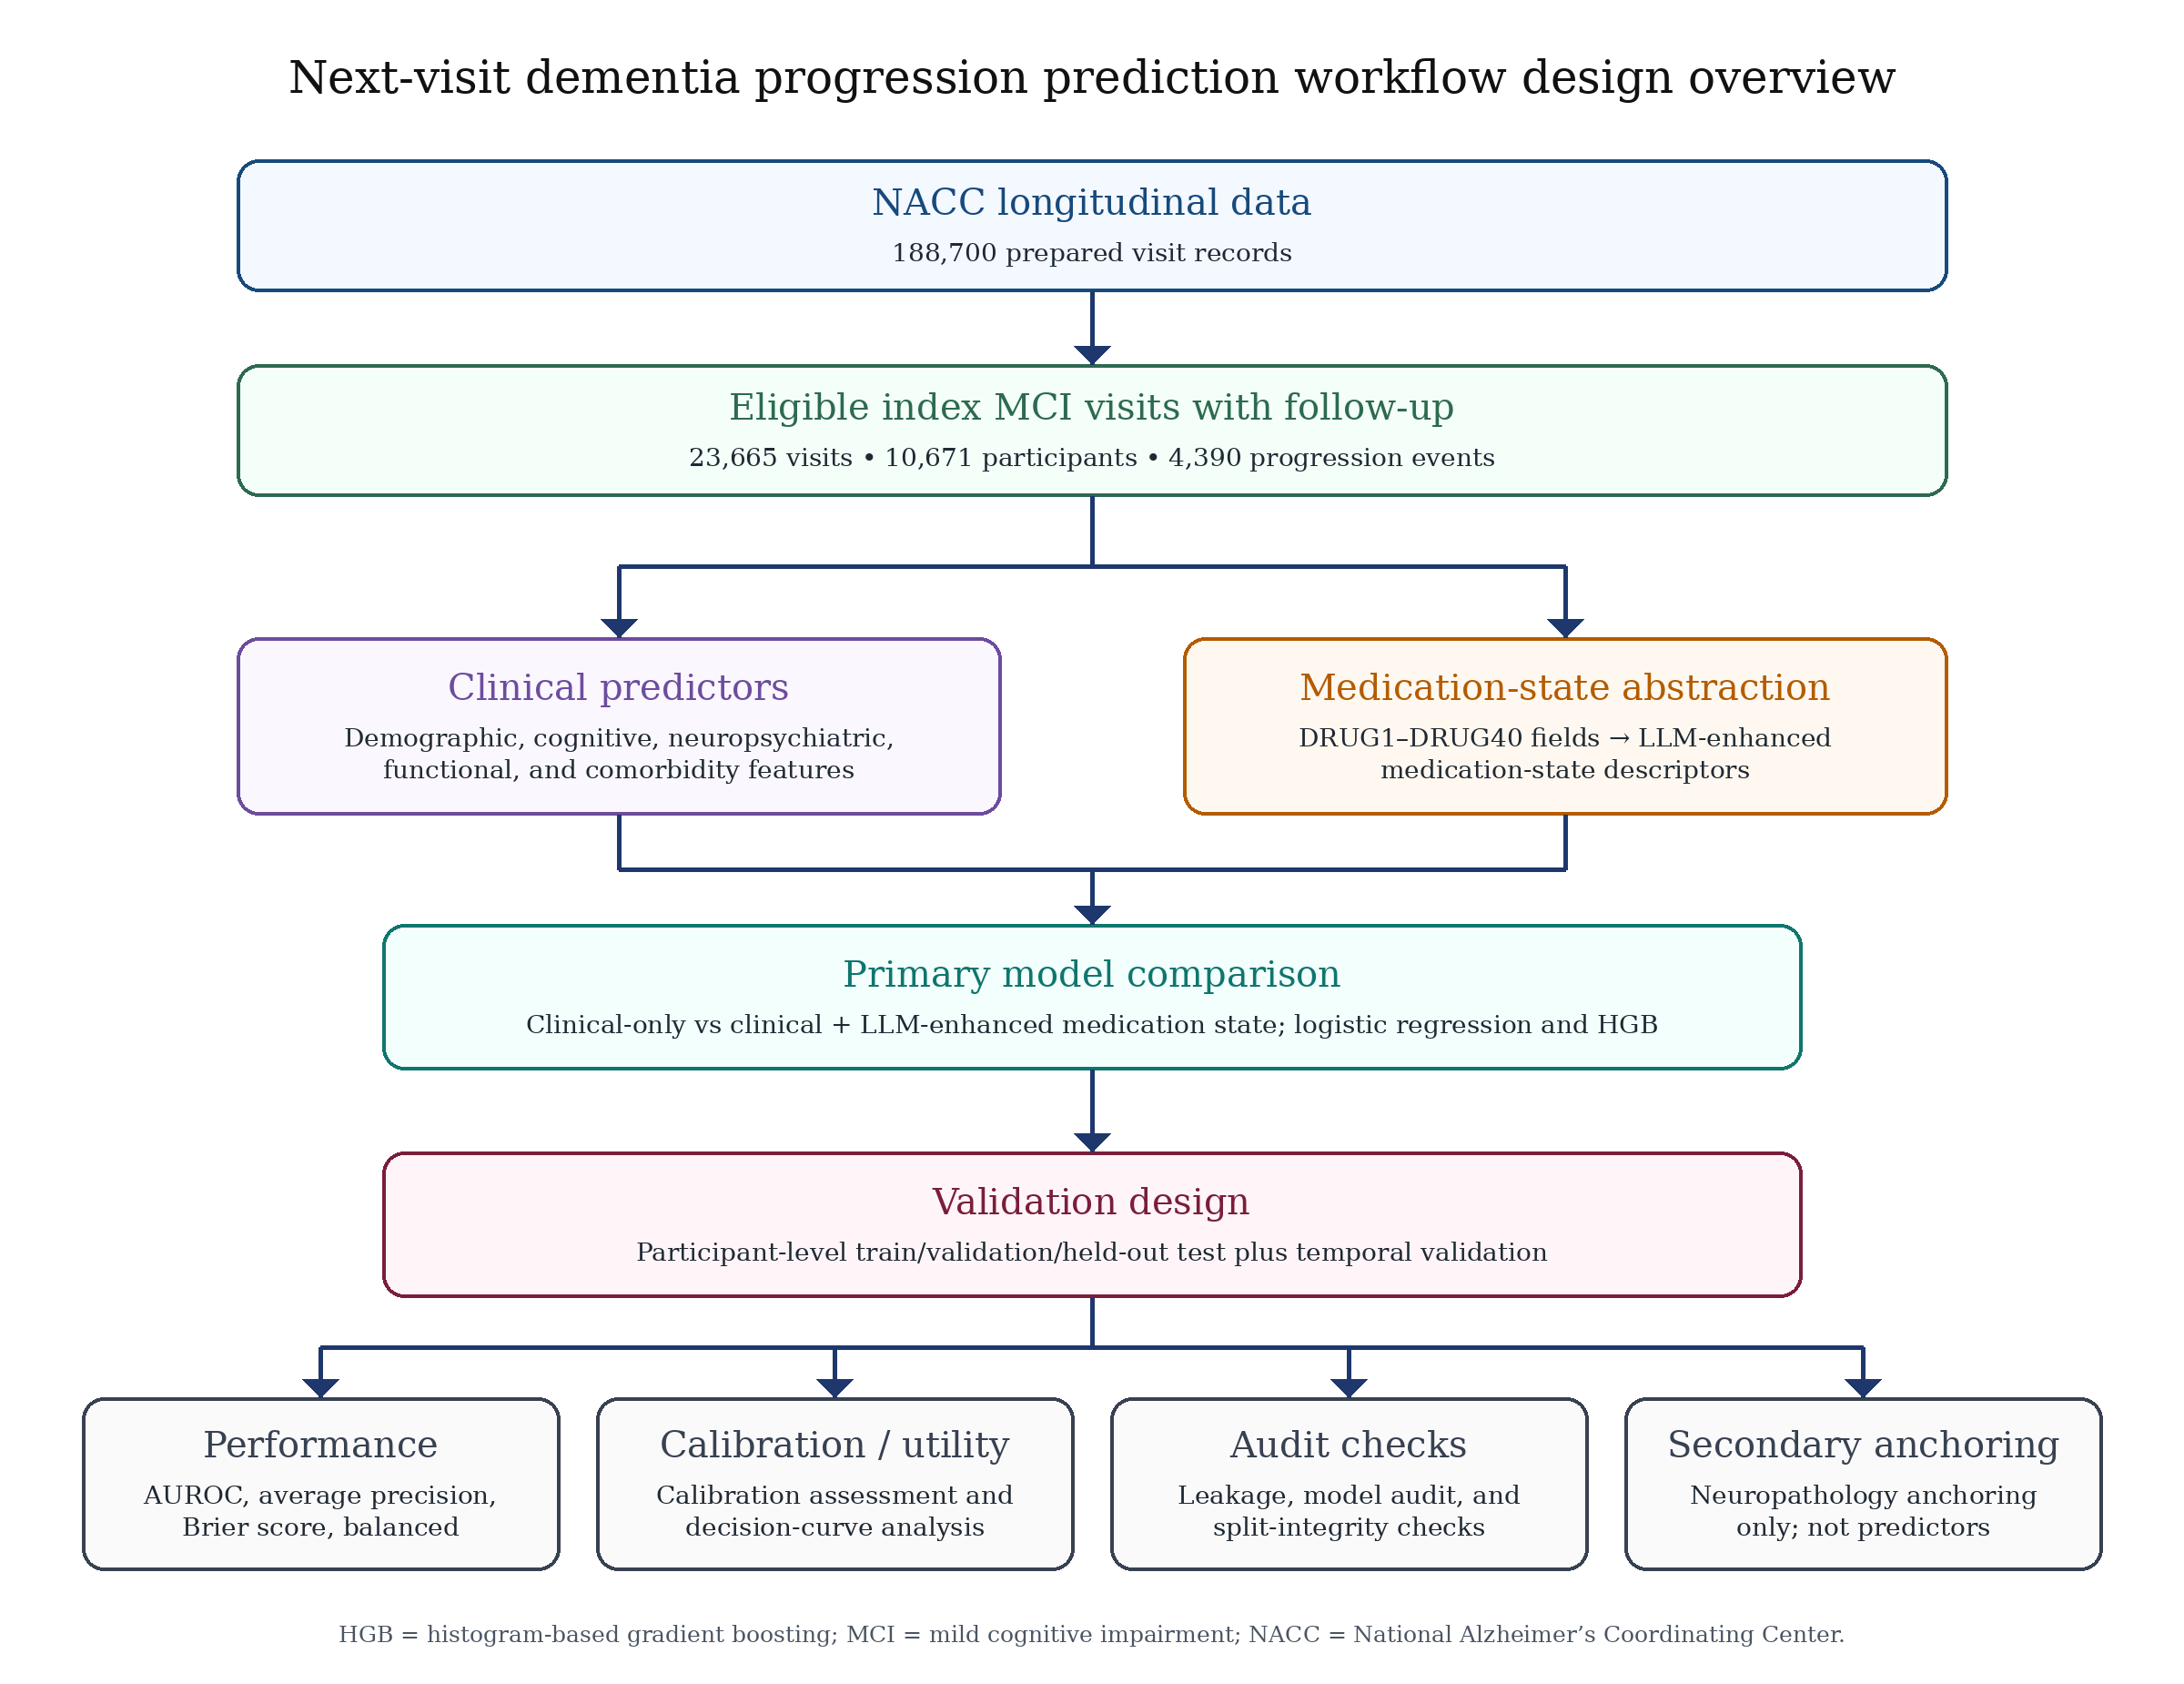

Saved: ../op/0_pipeline_arch_flow_diagram/fig_pipeline_arch_flow_v1.png


In [5]:
img, paths = run_all_pipeline_architecture_plots(show=True)
